In [2]:
from statistics import linear_regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

sales_data = pd.read_csv('AaltoIceCream_sales_data24.csv').drop(columns=['Observation'])

In [3]:
sales_data.head()

,Weekday,t_celsius,wind_ms,Sales_kg
0,1,26,4.3,117
1,2,24,4.9,194
2,3,21,4.8,85
3,4,19,3.3,91
4,5,22,5.9,217


In [4]:
sales_data.describe()

,Weekday,t_celsius,wind_ms,Sales_kg
count,200.000000,200.000000,200.000000,200.000000
mean,3.970000,18.350000,5.408000,154.730000
std,2.002285,5.202193,2.328076,56.252367
min,1.000000,10.000000,1.600000,15.000000
25%,2.000000,14.000000,3.600000,117.000000
50%,4.000000,18.000000,4.800000,148.000000
75%,6.000000,22.000000,6.900000,194.750000
max,7.000000,27.000000,13.800000,294.000000


In [5]:
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Weekday    200 non-null    int64  
 1   t_celsius  200 non-null    int64  
 2   wind_ms    200 non-null    float64
 3   Sales_kg   200 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 6.4 KB


<function matplotlib.pyplot.show(close=None, block=None)>

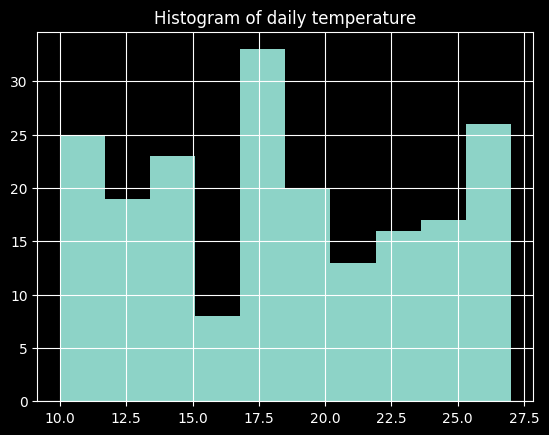

In [6]:
temp_hist = sales_data['t_celsius'].hist(bins=10)

plt.title('Histogram of daily temperature')
plt.show

<Axes: title={'center': 'Histogram of daily wind speed'}>

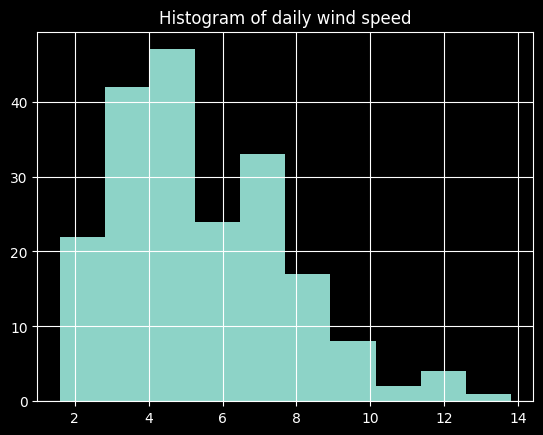

In [7]:
wind_hist = sales_data['wind_ms'].hist(bins=10)
plt.title('Histogram of daily wind speed')
wind_hist

<Axes: title={'center': 'Histogram of daily sales'}>

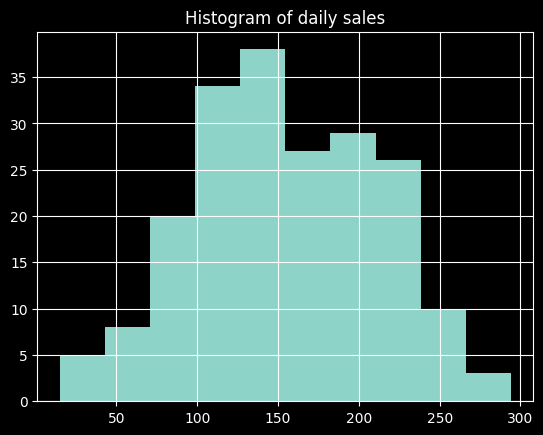

In [8]:
sales_hist = sales_data['Sales_kg'].hist(bins=10)
plt.title('Histogram of daily sales')
sales_hist

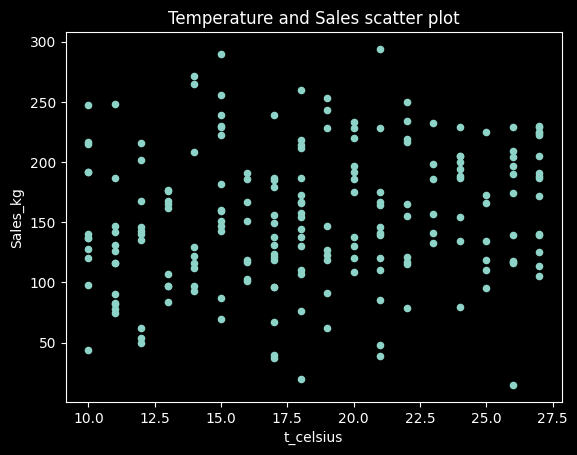

In [9]:
temp_scat = sales_data.plot.scatter(y='Sales_kg', x='t_celsius')

plt.title('Temperature and Sales scatter plot')
plt.show()

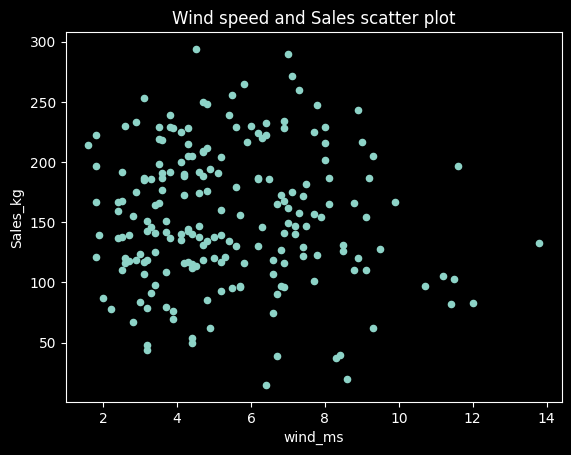

In [10]:
wind_scat = sales_data.plot.scatter(y='Sales_kg', x='wind_ms')

plt.title('Wind speed and Sales scatter plot')
plt.show()

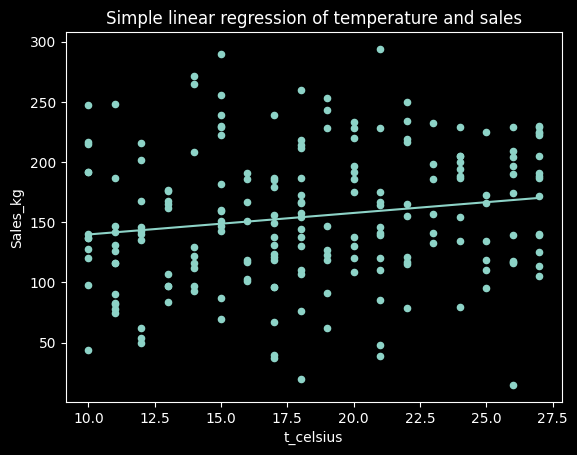

In [11]:
x = sales_data['t_celsius']
y = sales_data['Sales_kg']

slope = linear_regression(x, y).slope
intercept = linear_regression(x, y).intercept

temp_scat = sales_data.plot.scatter(y='Sales_kg', x='t_celsius')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line)
plt.title('Simple linear regression of temperature and sales')
plt.show()

In [12]:
linear_regression(sales_data['t_celsius'], sales_data['Sales_kg'])

LinearRegression(slope=1.7866307678024325, intercept=121.94532541082535)

In [13]:
# for simple linear regression, R^2 = correlation^2

r2 = sales_data['t_celsius'].corr(sales_data['Sales_kg'])**2
print(r2)

0.027299894900535946


In [14]:
sales_data[('is_monday')] = (sales_data['Weekday'] == 1).astype(int)

print(sales_data[['Weekday', 'is_monday']].head(10))
print(sales_data['is_monday'].value_counts())

   Weekday  is_monday
0        1          1
1        2          0
2        3          0
3        4          0
4        5          0
5        6          0
6        7          0
7        1          1
8        2          0
9        3          0
is_monday
0    171
1     29
Name: count, dtype: int64


In [15]:
monday_sales = sales_data.loc[sales_data['is_monday'] == 1, 'Sales_kg']
other_sales = sales_data.loc[sales_data['is_monday'] == 0, 'Sales_kg']

t_stat, p_two_sided = stats.ttest_ind(monday_sales, other_sales, equal_var=False)
print('t_stat:', t_stat)
print('two-sided p:', p_two_sided)

t_stat: -0.978145010637649
two-sided p: 0.3331006508196998


In [16]:
model = smf.ols('Sales_kg ~ Weekday + wind_ms + t_celsius', data=sales_data).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               Sales_kg   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     4.831
Date:                Wed, 04 Mar 2026   Prob (F-statistic):            0.00288
Time:                        15:06:56   Log-Likelihood:                -1082.1
No. Observations:                 200   AIC:                             2172.
Df Residuals:                     196   BIC:                             2185.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    109.8255     18.195      6.036      0.0

In [17]:
sales_data[('is_weekend')] = (sales_data['Weekday'].isin([6, 7])).astype(int)

print(sales_data[['Weekday', 'is_weekend']].head())


   Weekday  is_weekend
0        1           0
1        2           0
2        3           0
3        4           0
4        5           0


In [18]:
sales_data[('strong_wind')] = (sales_data['wind_ms'] >= 8).astype(int)
print(sales_data[['strong_wind', 'wind_ms']].head())

   strong_wind  wind_ms
0            0      4.3
1            0      4.9
2            0      4.8
3            0      3.3
4            0      5.9


In [19]:
model2 = smf.ols('Sales_kg ~ strong_wind + is_weekend + t_celsius', data=sales_data).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:               Sales_kg   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     8.575
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.23e-05
Time:                        15:06:56   Log-Likelihood:                -1076.9
No. Observations:                 200   AIC:                             2162.
Df Residuals:                     196   BIC:                             2175.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     117.2677     14.252      8.228      